# Exploratory Data Analysis of Adopted Cats

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

path = Path.cwd()
while not (path / 'data').exists():
    path = path.parent
os.chdir(path)

In [37]:
# inspect the cleaned data
df = pd.read_parquet('data/clean/clean_cats_data.parquet')
df.head(5)


,id,sex,sizeUOM,ageGroup,ageString,breedString,colorDetails,pictureCount,videoCount,adoptedDate,...,isSpecialNeeds,isDeclawed,ownerExperience,obedienceTraining,adultSexesOk,energyLevel,exerciseNeeds,vocalLevel,sheddingLevel,length_of_stay
2,10000193,Male,NaN,Adult,8 Years 8 Months,Domestic Short Hair / Mixed,NaN,5,0,2016-08-13 00:00:00+00:00,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0
9,10000236,Female,Pounds,Adult,10 Years 6 Months,Domestic Short Hair (short coat),NaN,4,0,2016-06-25 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0
10,10000242,Female,Pounds,Baby,6 Years 8 Months,Domestic Short Hair (short coat),White w/calico,2,0,2016-05-28 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0
11,10000252,Female,Pounds,Baby,6 Years 8 Months,Domestic Short Hair (short coat),Tabby w/white,2,0,2016-05-28 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0
20,10000959,Male,Pounds,Adult,NaN,Domestic Short Hair (short coat),NaN,1,0,2016-06-11 00:00:00+00:00,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0


In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 11929 entries, 2 to 149827
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     11929 non-null  str                
 1   sex                    11821 non-null  str                
 2   sizeUOM                9751 non-null   str                
 3   ageGroup               10915 non-null  str                
 4   ageString              11420 non-null  str                
 5   breedString            11929 non-null  str                
 6   colorDetails           3568 non-null   str                
 7   pictureCount           11929 non-null  int64              
 8   videoCount             11929 non-null  int64              
 9   adoptedDate            11929 non-null  datetime64[us, UTC]
 10  isCurrentVaccinations  7679 non-null   object             
 11  newPeopleReaction      5349 non-null   str                
 12  sizeC

## Columns with the least available data to analyze:
    ownerExperience
    obedienceTraining
    exerciseNeeds
    vocalLevel
    sheddingLevel

These fields can still be evaluated against our dependent variable, but our analysis will be more precise if we analyze correlations of length_of_stay with other cat characteristics.

In [39]:
# Analyze the dataframe's quantitative variables
df.describe()

,pictureCount,videoCount,sizeCurrent,length_of_stay
count,11929.000000,11929.000000,4643.000000,11929.000000
mean,2.803085,0.055327,5.229440,74.283846
std,2.453294,0.318432,3.746718,203.906184
min,0.000000,0.000000,0.500000,0.000000
25%,1.000000,0.000000,2.815000,8.000000
50%,2.000000,0.000000,4.000000,24.000000
75%,4.000000,0.000000,7.000000,62.000000
max,25.000000,8.000000,99.599998,3672.000000


Length of stay ranges anywhere from 0 days to 3672 days. Ordering the dataset by least to most days of stay, the middle 50% of cats took anywhere between 8-62 days to be adopted as of becoming available. Seventy-five percent were adopted in 2 months or less, with the median taking 24 days. 

In [40]:
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)

IQR = Q3 - Q1
lower_boundary = Q1-1.5*IQR
upper_boundary = Q3+1.5*IQR

print("Identifying Outliers---")
print("Lower Boundary: ",lower_boundary)
print("Upper Boundary: ",upper_boundary)

outliers_df = df[df['length_of_stay'] > upper_boundary]
outliers_df.info()


Identifying Outliers---
Lower Boundary:  -73.0
Upper Boundary:  143.0
<class 'pandas.DataFrame'>
Index: 1223 entries, 32 to 142650
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     1223 non-null   str                
 1   sex                    1212 non-null   str                
 2   sizeUOM                1011 non-null   str                
 3   ageGroup               1143 non-null   str                
 4   ageString              1200 non-null   str                
 5   breedString            1223 non-null   str                
 6   colorDetails           356 non-null    str                
 7   pictureCount           1223 non-null   int64              
 8   videoCount             1223 non-null   int64              
 9   adoptedDate            1223 non-null   datetime64[us, UTC]
 10  isCurrentVaccinations  909 non-null    object             
 11 

Out of a total 11,929 cats, 1,223 had an outlier number of days spent in adoption. These records need to be considered before diving into machine learning for this dataset.

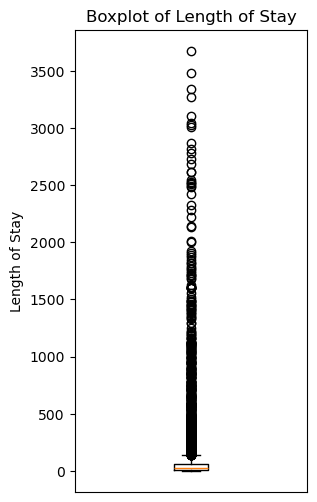

In [41]:
plt.figure(figsize=(3, 6))
plt.boxplot(df['length_of_stay'])

plt.ylabel('Length of Stay')
plt.title('Boxplot of Length of Stay')
plt.xticks([])
plt.show()

The box plot visualizes the data set's extreme outliers.

In [42]:
df['breedString'].describe()

count                                11929
unique                                 714
top       Domestic Short Hair (short coat)
freq                                  2853
Name: breedString, dtype: object

While there are 714 different uniquely described breeds in the data, the domestic short hair, short coat cat breed makes up ~24% of the adopted cats.

In [43]:
pivot_df = df['breedString'].value_counts().to_frame('Count')
pivot_df.index.name = 'Breed'
print("Sorted By Frequency:")
pivot_df.head(10)

Sorted By Frequency:


,Count
Breed,
Domestic Short Hair (short coat),2853
Domestic Short Hair / Mixed (short coat),1634
Domestic Short Hair / Mixed,1060
Domestic Short Hair,909
Domestic Medium Hair (medium coat),517
Domestic Short Hair / Tabby / Mixed (short coat),292
Domestic Long Hair (long coat),215
Domestic Short Hair / Tabby (short coat),176
Domestic Medium Hair / Mixed,174


The top 4 most commonly named breeds of adopted cats have short hair, making up ~54% of all the cats- as opposed to those with long or medium hair.

In [44]:
df['sheddingLevel'].value_counts().to_frame('Count')

,Count
sheddingLevel,
Moderate,2290
None,21
High,19


There is less variety in shedding levels to analyze than anticipated- with almost all animals shedding a moderate amount.

In [45]:
df['sizeGroup'].describe()

count       7722
unique         4
top       Medium
freq        4554
Name: sizeGroup, dtype: object

In [55]:
df['sizeGroup'].value_counts().to_frame('Count')

,Count
sizeGroup,
Medium,4554
Small,2486
Large,632
X-Large,50


A vast majority of cats assigned a size group label are small or medium.

In [56]:
df['sizeUOM'].value_counts().to_frame('Count')

,Count
sizeUOM,
Pounds,9740
Ounces,9
Kilograms,1
Centimeters,1


If checking the correlation of size versus length of stay, we'd need to modify or filter out the few rows that have a different unit of measurement for size

In [57]:
df['sizeCurrent'].value_counts().to_frame('Count')

,Count
sizeCurrent,
3.00,591
2.00,521
4.00,349
5.00,237
8.00,232
...,...
12.20,1
4.99,1
14.72,1


In [62]:
#  What does the range of highest to lowest cat weights look like?
lb_df = df[df['sizeUOM'] == 'Pounds']
(lb_df['sizeCurrent']
    .sort_values(ascending=False)
    .to_frame()
    .reset_index(drop=True)
    .rename(columns={'sizeCurrent': 'Weight (lbs)'}))

,Weight (lbs)
0,99.599998
1,29.000000
2,28.000000
3,22.000000
4,21.580000
...,...
9735,NaN
9736,NaN
9737,NaN
9738,NaN


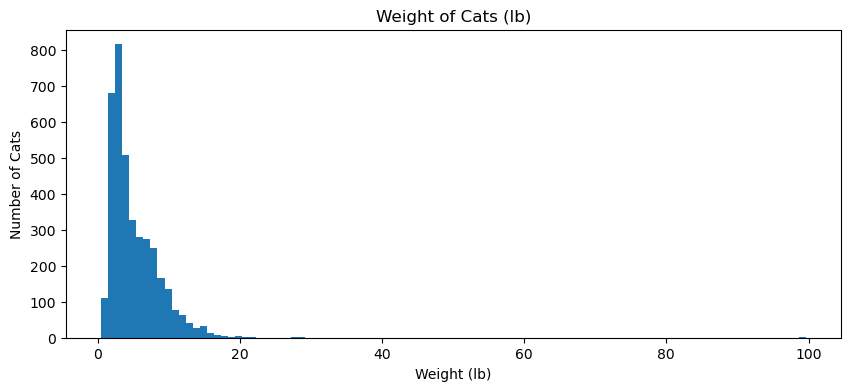

In [50]:
plt.figure(figsize=(10, 4))
plt.hist(lb_df['sizeCurrent'], bins=100)

plt.title('Weight of Cats (lb)')
plt.xlabel('Weight (lb)')
plt.ylabel('Number of Cats')
plt.show()

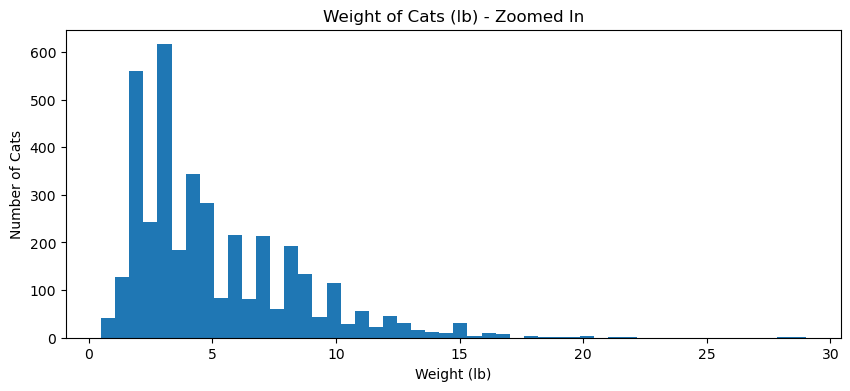

In [51]:
#  Excluding the single 99lb cat to zoom in on the rest of the data

lb_filtered_df = lb_df[lb_df['sizeCurrent'] < 99]

plt.figure(figsize=(10, 4))
plt.hist(lb_filtered_df['sizeCurrent'], bins=50)

plt.title('Weight of Cats (lb) - Zoomed In')
plt.xlabel('Weight (lb)')
plt.ylabel('Number of Cats')
plt.show()

Average adult cat weighs between 8-12 lb, with most weighing around 10 lb (petmd). Since a majority of cats in the data are below that range, there may be a lot of younger or malnourished cats.

PetMD: https://www.petmd.com/cat/general-health/average-weight-cats

In [65]:
df['ageGroup'].describe()

count     10915
unique        4
top        Baby
freq       5360
Name: ageGroup, dtype: object

In [52]:
df['ageGroup'].value_counts()

ageGroup
Baby      5360
Young     3020
Adult     2379
Senior     156
Name: count, dtype: int64

A further look shows that most of the adopted cats in our data are indeed young or baby cats.

## EDA Summary

**Completeness of data ranges widely across columns,** with some having many more missing values - which should be considered when picking which variables to test for correlations with the dependent variable 'length_of_stay'

**75% of cats took 2 months or less to get adopted, with 50% taking 24 days, or around a month.** At the same time, about 10% of the cats stayed unadopted for an abnormally high amount of days, ranging up to 10 years. Those data points' variables can be further inspected to check if the cats share any characteristics such as age, breed, size, etc.

**A majority of adopted cats have short hair,** - since cat breed strings are distinguished by their hair length - cat breeds with short hair but different names can be bundled into one category, creating 3 distinct categories - short, medium and long, then compared on their desirability.

**Shedding Levels showed little variety**, making it less relevant for correlation and machine learning purposes.

**Most commonly identified cats in the data were labeled as medium, with small in second place,** both summing up to ~91% of all the adopted cats that did get a label.

**Most cats weighed less than 10 lb - the average weight of an adult cat,** which prompted a check of the age group column, which revealed that ~77% of labeled cats were babies or young (~70 of all cats in dataset if counting those uncategorized). Senior cats are the least present in the data - which makes our conclusions on senior cats less reliable. This data imbalance also needs to be accounted for when the data is modeled.


**Special Note:** not all available variables were explored, and diving deeper can unlock other insights that are not covered here.